Deep Learning based Object Detection 

In [28]:
import os
import cv2
import numpy as np
import urllib.request          # ← not just urllib
import matplotlib.pyplot as plt
%matplotlib inline

In [29]:
MODEL_DIR  = "models/ssd_mobilenet_v2_coco_2018_03_29"

modelFile  = os.path.join(MODEL_DIR, "frozen_inference_graph.pb")
configFile = os.path.join(MODEL_DIR, "ssd_mobilenet_v2_coco_2018_03_29.pbtxt")
classFile  = os.path.join(MODEL_DIR, "coco_class_labels.txt")

if not os.path.isfile(modelFile):
    model_url = ("http://download.tensorflow.org/models/object_detection/"
           "ssd_mobilenet_v2_coco_2018_03_29.tar.gz")
    archive_path = "models/ssd_mobilenet_v2_coco_2018_03_29.tar.gz"
    os.makedirs("models", exist_ok=True)
    urllib.request.urlretrieve(model_url, archive_path)        # ← with a file name
    !tar -xzf {archive_path} -C models
    os.remove(archive_path)

for required_file in (modelFile, configFile, classFile):
    print("OK " if os.path.isfile(required_file) else "MISSING", required_file)

OK  models/ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb
OK  models/ssd_mobilenet_v2_coco_2018_03_29/ssd_mobilenet_v2_coco_2018_03_29.pbtxt
OK  models/ssd_mobilenet_v2_coco_2018_03_29/coco_class_labels.txt


In [30]:
with open(classFile) as class_file:
    labels = class_file.read().split("\n")
print(labels)

['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', '']


In [31]:
detection_net = cv2.dnn.readNetFromTensorflow(modelFile, configFile)

In [32]:
def detect_objects(detection_net, image):
    input_size = 300

    input_blob = cv2.dnn.blobFromImage(image, 1.0, size=(input_size,input_size), mean=(0,0,0), swapRB = True, crop = False)

    detection_net.setInput(input_blob)

    objects = detection_net.forward()
    return objects

In [33]:
def display_text(image, text, text_x, text_y):

    textSize = cv2.getTextSize(text, FONTFACE, FONT_SCALE, THICKNESS)
    text_dimensions = textSize[0]
    baseline = textSize[1]

    cv2.rectangle(image, (text_x,text_y-text_dimensions[1] - baseline), (text_x + text_dimensions[0], text_y + baseline), (0,0,0), cv2.FILLED);

    cv2.putText(image,text,(text_x, text_y-5), FONTFACE, FONT_SCALE, (0,255,255), THICKNESS, cv2.LINE_AA)

In [44]:
FONTFACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.7
THICKNESS = 1

def display_objects(image, objects, threshold=0.2):
    image_height = image.shape[0]; image_width = image.shape[1]

    for object_index in range(objects.shape[2]):
        classId = int(objects[0,0,object_index,1])
        score = float(objects[0,0,object_index,2])

        box_x = int(objects[0,0,object_index,3] * image_width)
        box_y = int(objects[0,0,object_index,4] * image_height)
        box_width = int(objects[0,0,object_index,5] * image_width - box_x)
        box_height = int(objects[0,0,object_index,6] * image_height - box_y)

        if score > threshold:
            display_text(image, '{}'.format(labels[classId]), box_x, box_y)
            cv2.rectangle(image, (box_x,box_y), (box_x+box_width,box_y+box_height), (255,255,255), 2)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(30,10)); plt.imshow(image_rgb); plt.show();

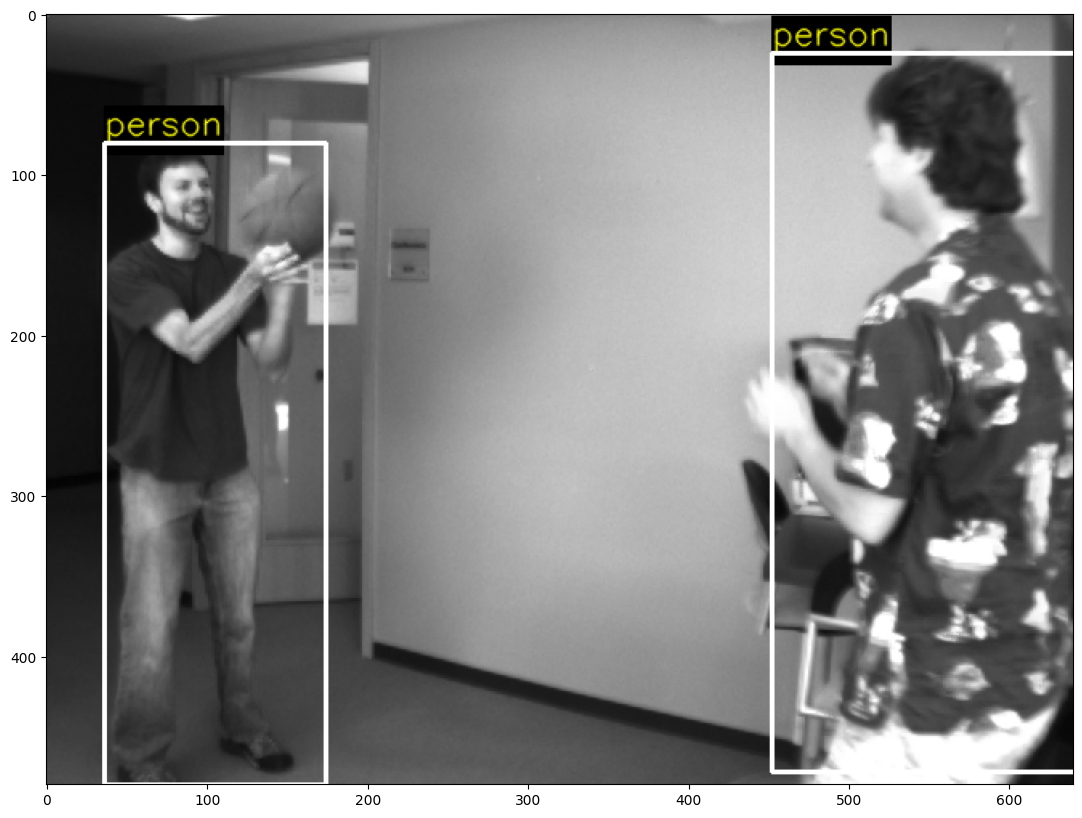

In [46]:
image = cv2.imread('data/images/basketball1.png')
objects = detect_objects(detection_net,image)
display_objects(image, objects)